# Axis of Awesome — Chord Progression Analysis

**Research question:** How many songs across three collections (*lastfm*, *suno*, *udio*) are based on the **Axis of Awesome** chord progression?

## The Axis progression is a SEQUENCE, not a vocabulary

The Axis of Awesome is the **cyclic loop** I → V → vi → IV (and its minor equivalents).  
A song is "axis-based" when this loop **repeats as the harmonic structure** — not merely because it uses the chords I, V, vi, IV (which are the 4 most common chords in Western music).

## Method

1. **Define axis rotations** — 4 cyclic rotations per set (12 total), NOT all 24 permutations  
2. **Scan 4-chord sliding windows** — on the collapsed chord sequence (consecutive duplicates removed)  
3. **Compute window match rate** — `axis_windows / total_windows` per song  
4. **Classify** — a song is "axis-based" when ≥ 50 % of its windows match an axis rotation (= the loop dominates the song's harmony)  
5. **Compare collections** — distribution of match rates across the three corpora

In [1]:
import os, re
from collections import Counter, defaultdict
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = '/workspace/dataset'
COLLECTIONS = ['lastfm', 'suno', 'udio']
colors = {'lastfm': '#51BFFF', 'suno': '#FFC400', 'udio': '#FF5B0E'}

# Window rule shared with forming_n_gram_datasets_ACE.ipynb (gate=False):
# every 4-chord window after consecutive de-duplication is kept, except windows
# built from a single root (i I i I etc., only mode/case alternation).
# Gate-dependent figures are saved with this suffix.
GATE_SUFFIX = '_gate_false'

# ═══════════════════════════════════════════════════════════════════════════════
# 12-TONE CHORD NORMALISER
# ═══════════════════════════════════════════════════════════════════════════════
_DEG_SEMI = {'I': 0, 'II': 2, 'III': 4, 'IV': 5, 'V': 7, 'VI': 9, 'VII': 11}
_SEMI_MAJ = {0:'I', 1:'bII', 2:'II', 3:'bIII', 4:'III', 5:'IV',
             6:'#IV', 7:'V', 8:'bVI', 9:'VI', 10:'bVII', 11:'VII'}
_SEMI_MIN = {0:'i', 1:'bii', 2:'ii', 3:'biii', 4:'iii', 5:'iv',
             6:'#iv', 7:'v', 8:'bvi', 9:'vi', 10:'bvii', 11:'vii'}
_CHORD_RE = re.compile(
    r'^([#b]*)(VII|VI|V|IV|III|II|I|vii|vi|v|iv|iii|ii|i)$')

def normalize_chord(ch):
    """Resolve enharmonics via 12-tone semitone mapping."""
    norm = re.sub(r'^B(?=[IViv])', 'b', ch)
    m = _CHORD_RE.match(norm)
    if not m:
        return ch
    acc_str, deg = m.group(1), m.group(2)
    acc = acc_str.count('#') - acc_str.count('b')
    is_minor = deg[0].islower()
    semi = (_DEG_SEMI[deg.upper()] + acc) % 12
    return _SEMI_MIN[semi] if is_minor else _SEMI_MAJ[semi]

for inp, exp in [('#V','bVI'),('#VII','I'),('##IV','V'),('BVII','bVII'),
                 ('BVI','bVI'),('bVI','bVI'),('I','I'),('vi','vi')]:
    assert normalize_chord(inp) == exp, f'{inp} → {normalize_chord(inp)} ≠ {exp}'

# ═══════════════════════════════════════════════════════════════════════════════
# AXIS OF AWESOME — 3 chord sets, ALL PERMUTATIONS
# ═══════════════════════════════════════════════════════════════════════════════
import itertools

AXIS_CHORD_SETS = [
    ('I', 'V', 'vi', 'IV'),           # major
    ('i', 'bVI', 'III', 'bVII'),      # minor
    ('i', 'bVI', 'bIII', 'bVII'),     # minor variant
]
AXIS_SET_LABELS = ['major', 'minor', 'minor variant']

# All permutations per set — any ordering of the axis chords is valid
AXIS_ROTATIONS = set()
for axis_set in AXIS_CHORD_SETS:
    for perm in itertools.permutations(axis_set):
        AXIS_ROTATIONS.add(perm)

# Axis vocabulary (for secondary descriptive stats only)
AXIS_VOCAB = set()
for s in AXIS_CHORD_SETS:
    AXIS_VOCAB |= set(s)

# ═══════════════════════════════════════════════════════════════════════════════
# HELPER FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════════════

def parse_functional_lab(path):
    """Parse _functional.lab → list of normalised chord labels."""
    labels = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 3 and parts[2] != 'N':
                labels.append(normalize_chord(parts[2]))
    return labels

def collapse_repeats(seq):
    """Remove consecutive duplicates: [I,I,V,V,vi] → [I,V,vi]"""
    if not seq:
        return []
    out = [seq[0]]
    for s in seq[1:]:
        if s != out[-1]:
            out.append(s)
    return out

def is_single_root(window):
    """True when all chords share one root (only mode/case differs): i,I,i,I."""
    return len(set(c.lower() for c in window)) == 1

def axis_window_match_rate(collapsed):
    """Slide a 4-chord window over the collapsed sequence.
    Single-root windows are excluded (same rule as the tetragram dataset).
    Return (n_matches, n_windows, match_rate_pct)."""
    if len(collapsed) < 4:
        return 0, 0, 0.0
    n_windows = 0
    n_matches = 0
    for i in range(len(collapsed) - 3):
        window = tuple(collapsed[i:i+4])
        if is_single_root(window):
            continue
        n_windows += 1
        if window in AXIS_ROTATIONS:
            n_matches += 1
    rate = n_matches / n_windows * 100 if n_windows > 0 else 0.0
    return n_matches, n_windows, rate

# ── Summary ──
print(f'Axis chord sets: {len(AXIS_CHORD_SETS)}')
print(f'All valid axis permutations: {len(AXIS_ROTATIONS)}')
print(f'Normaliser checks passed ✓')
print('Setup complete')

Axis chord sets: 3
All valid axis permutations: 72
Normaliser checks passed ✓
Setup complete


In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# FONT — Fira Code for all plots in this notebook
# ═══════════════════════════════════════════════════════════════════════════════
plt.rcParams['font.family'] = 'Fira Code'
plt.rcParams['font.monospace'] = ['Fira Code']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Fira Code'
plt.rcParams['mathtext.it'] = 'Fira Code'
plt.rcParams['mathtext.bf'] = 'Fira Code'


## Step 1 — The axis permutations

Any ordering of the axis chord set is a valid axis pattern.  
All 24 permutations per set are accepted.

In [3]:
# ============================================================
# STEP 1 — Show all valid axis permutations
# ============================================================

for idx, (axis_set, label) in enumerate(zip(AXIS_CHORD_SETS, AXIS_SET_LABELS)):
    print(f'━━ Set {idx} ({label}): {list(axis_set)} ━━')
    for perm in sorted(itertools.permutations(axis_set)):
        print(f'  {"→".join(perm)}')
    print()

print(f'TOTAL valid axis permutations: {len(AXIS_ROTATIONS)}')

━━ Set 0 (major): ['I', 'V', 'vi', 'IV'] ━━
  I→IV→V→vi
  I→IV→vi→V
  I→V→IV→vi
  I→V→vi→IV
  I→vi→IV→V
  I→vi→V→IV
  IV→I→V→vi
  IV→I→vi→V
  IV→V→I→vi
  IV→V→vi→I
  IV→vi→I→V
  IV→vi→V→I
  V→I→IV→vi
  V→I→vi→IV
  V→IV→I→vi
  V→IV→vi→I
  V→vi→I→IV
  V→vi→IV→I
  vi→I→IV→V
  vi→I→V→IV
  vi→IV→I→V
  vi→IV→V→I
  vi→V→I→IV
  vi→V→IV→I

━━ Set 1 (minor): ['i', 'bVI', 'III', 'bVII'] ━━
  III→bVI→bVII→i
  III→bVI→i→bVII
  III→bVII→bVI→i
  III→bVII→i→bVI
  III→i→bVI→bVII
  III→i→bVII→bVI
  bVI→III→bVII→i
  bVI→III→i→bVII
  bVI→bVII→III→i
  bVI→bVII→i→III
  bVI→i→III→bVII
  bVI→i→bVII→III
  bVII→III→bVI→i
  bVII→III→i→bVI
  bVII→bVI→III→i
  bVII→bVI→i→III
  bVII→i→III→bVI
  bVII→i→bVI→III
  i→III→bVI→bVII
  i→III→bVII→bVI
  i→bVI→III→bVII
  i→bVI→bVII→III
  i→bVII→III→bVI
  i→bVII→bVI→III

━━ Set 2 (minor variant): ['i', 'bVI', 'bIII', 'bVII'] ━━
  bIII→bVI→bVII→i
  bIII→bVI→i→bVII
  bIII→bVII→bVI→i
  bIII→bVII→i→bVI
  bIII→i→bVI→bVII
  bIII→i→bVII→bVI
  bVI→bIII→bVII→i
  bVI→bIII→i→bVII
  bVI→b

## Step 2 — Scan every song: 4-chord sliding window match rate

For each song:
1. Parse and normalise chords, collapse consecutive duplicates  
2. Slide a **4-chord window** across the sequence  
3. Check each window against **all valid axis permutations**  
4. Compute **match rate** = axis_windows / total_windows  

This measures whether the song's harmonic structure uses the axis chord set — any ordering is valid.

In [4]:
# ============================================================
# STEP 2 — Scan all songs: 4-chord window match rate
# ============================================================

total_songs   = {}
all_song_data = {}

for col in COLLECTIONS:
    root = os.path.join(BASE_DIR, col)
    songs = []
    for song_id in sorted(os.listdir(root)):
        song_dir = os.path.join(root, song_id)
        if not os.path.isdir(song_dir):
            continue
        fp = os.path.join(song_dir, f'{song_id}_functional.lab')
        if not os.path.isfile(fp):
            continue

        chords = parse_functional_lab(fp)
        collapsed = collapse_repeats(chords)
        n_matches, n_windows, match_rate = axis_window_match_rate(collapsed)

        # Also compute vocabulary % for secondary comparison
        if chords:
            vocab_pct = sum(1 for ch in chords if ch in AXIS_VOCAB) / len(chords) * 100
        else:
            vocab_pct = 0.0

        songs.append({
            'file': song_id,
            'n_chords': len(chords),
            'n_collapsed': len(collapsed),
            'axis_matches': n_matches,
            'axis_windows': n_windows,
            'match_rate': match_rate,       # ← PRIMARY METRIC
            'vocab_pct': vocab_pct,         # ← secondary
        })

    total_songs[col] = len(songs)
    all_song_data[col] = songs

# Report
print('Step 2 — 4-chord window scan complete')
print(f'{"Collection":>10}  {"Songs":>7}  {"Avg chords":>11}  {"Avg collapsed":>14}')
print('─' * 50)
for col in COLLECTIONS:
    avg_ch = np.mean([s['n_chords'] for s in all_song_data[col]])
    avg_co = np.mean([s['n_collapsed'] for s in all_song_data[col]])
    print(f'{col:>10}  {total_songs[col]:>7,}  {avg_ch:>11.1f}  {avg_co:>14.1f}')

Step 2 — 4-chord window scan complete
Collection    Songs   Avg chords   Avg collapsed
──────────────────────────────────────────────────
    lastfm   18,916         98.2            78.2
      suno   18,978         85.3            75.8
      udio   19,031         61.6            51.8


## Supplementary — Vocabulary analysis (secondary, for context)

The vocabulary approach (what % of chords are I/IV/V/vi) is included for **comparison only**.  
It does NOT answer the research question because I, IV, V, vi are the most common chords in ALL Western music.

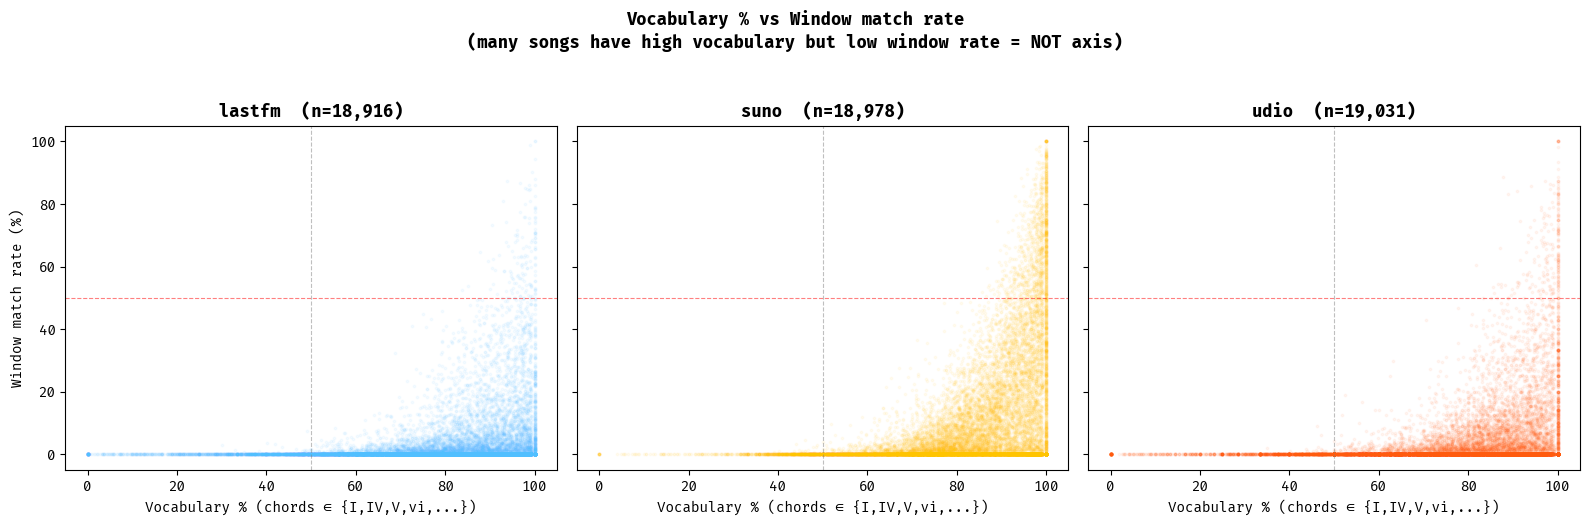

Key insight from the scatter plot:
  Songs can have 80–100% axis VOCABULARY but 0% axis WINDOW rate.
  These are diatonic songs using I, IV, V, vi in non-axis order.
  The vocabulary method would wrongly classify them as "axis-based."

  lastfm: 8,301 songs (43.9%) have ≥80% axis vocabulary but <5% window match
  suno: 5,888 songs (31.0%) have ≥80% axis vocabulary but <5% window match
  udio: 7,659 songs (40.2%) have ≥80% axis vocabulary but <5% window match


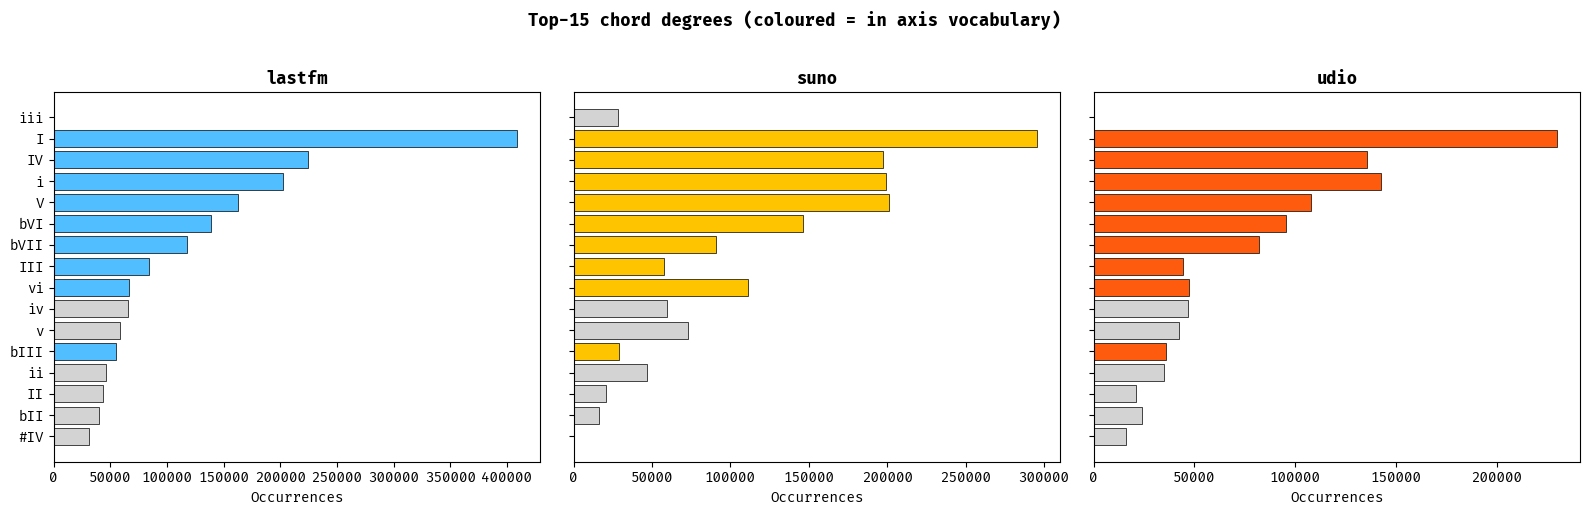

In [5]:
# ── Supplementary: vocabulary vs window scatter plot ──

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, sharex=True)
for ax, col in zip(axes, COLLECTIONS):
    x_vals = [s['vocab_pct'] for s in all_song_data[col]]
    y_vals = [s['match_rate'] for s in all_song_data[col]]
    ax.scatter(x_vals, y_vals, alpha=0.05, s=3, color=colors[col])
    ax.set_title(f'{col}  (n={total_songs[col]:,})', fontweight='bold')
    ax.set_xlabel('Vocabulary % (chords ∈ {I,IV,V,vi,...})')
    ax.axhline(50, ls='--', color='red', lw=0.8, alpha=0.5)
    ax.axvline(50, ls='--', color='grey', lw=0.8, alpha=0.5)
axes[0].set_ylabel('Window match rate (%)')
fig.suptitle('Vocabulary % vs Window match rate\n'
             '(many songs have high vocabulary but low window rate = NOT axis)',
             fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

# ── Summary stats ──
print('Key insight from the scatter plot:')
print('  Songs can have 80–100% axis VOCABULARY but 0% axis WINDOW rate.')
print('  These are diatonic songs using I, IV, V, vi in non-axis order.')
print('  The vocabulary method would wrongly classify them as "axis-based."')
print()
for col in COLLECTIONS:
    high_vocab_low_window = sum(
        1 for s in all_song_data[col]
        if s['vocab_pct'] >= 80 and s['match_rate'] < 5
    )
    n = total_songs[col]
    print(f'  {col}: {high_vocab_low_window:,} songs ({high_vocab_low_window/n*100:.1f}%) '
          f'have ≥80% axis vocabulary but <5% window match')

# ── Degree spectrum ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, col in zip(axes, COLLECTIONS):
    all_chords = []
    for s in all_song_data[col]:
        chords = parse_functional_lab(
            os.path.join(BASE_DIR, col, s['file'], f'{s["file"]}_functional.lab'))
        all_chords.extend(chords)
    ct = Counter(all_chords)
    labels_sorted = [lbl for lbl, _ in ct.most_common(15)]
    counts_sorted = [ct[lbl] for lbl in labels_sorted]
    bar_colors = [colors[col] if lbl in AXIS_VOCAB else 'lightgrey'
                  for lbl in labels_sorted]
    ax.barh(labels_sorted[::-1], counts_sorted[::-1],
            color=bar_colors[::-1], edgecolor='black', linewidth=0.5)
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xlabel('Occurrences')
fig.suptitle('Top-15 chord degrees (coloured = in axis vocabulary)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Tetragram axis analysis

1. Read each song's `_functional.lab` → normalise chords  
2. Collapse consecutive duplicates (no progression = no tetragram)  
3. Sliding window of 4 → tetragrams; single-root windows (i I i I, only mode/case alternation) are excluded, matching the `_gate_false` dataset rule  
4. Each tetragram checked: is its chord set ⊆ an axis chord set (≥3 unique)?  
5. **Axis % = axis tetragrams / total tetragrams**

**Note:** An axis-based song does NOT need 100% axis tetragrams.  
Bridges, intros, outros use simpler progressions (e.g. I→V→IV→I).  
A song with axis tetragrams in its verses/choruses is still axis-based.  
**≥ 10% axis tetragrams** = the axis loop is a structural element of the song.

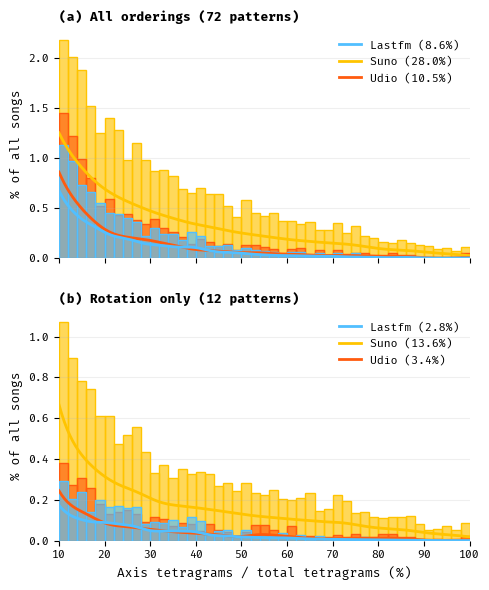


Tetragram axis classification — ALL ORDERINGS (72)
 Threshold Meaning                         lastfm              suno              udio
--------------------------------------------------------------------------------------
     >=50% axis dominates           152 (  0.8%)    1231 (  6.5%)     249 (  1.3%)
     >=25% strong axis              664 (  3.5%)    3026 ( 16.1%)     818 (  4.4%)
     >=10% axis-based song         1618 (  8.6%)    5260 ( 28.0%)    1960 ( 10.5%)
      >=5% axis present            2528 ( 13.5%)    6618 ( 35.2%)    3008 ( 16.1%)
      >=1% trace of axis           4670 ( 24.9%)    8678 ( 46.2%)    4900 ( 26.3%)
       >0% any axis tetragram      5034 ( 26.9%)    8864 ( 47.2%)    5066 ( 27.1%)

Tetragram axis classification — ROTATION ONLY (12, Richards)
 Threshold Meaning                         lastfm              suno              udio
--------------------------------------------------------------------------------------
     >=50% axis dominates            57 ( 

In [6]:
# ── 7. FINAL OVERLAY (2-panel) — axis distribution: all orderings vs rotation-only ──
# Left  : all 72 orderings (axis-family, the original measure).
# Right : 12 rotations only (Richards-faithful strict loop).
# Draw order per panel: suno (back) -> udio (middle) -> lastfm (front).
import matplotlib.colors as mcolors
import itertools
from scipy.stats import gaussian_kde

# --- axis pattern sets: strict 12 rotations and full 72 permutations ---
_CANON = {'major': ('I', 'V', 'vi', 'IV'),
          'minor': ('i', 'bVI', 'III', 'bVII'),
          'mvar':  ('i', 'bVI', 'bIII', 'bVII')}
_CANON = {k: tuple(normalize_chord(c) for c in v) for k, v in _CANON.items()}
_ROT, _PERM_SETS = set(), set()
for _c in _CANON.values():
    _c = list(_c)
    _ROT |= {tuple(_c[i:] + _c[:i]) for i in range(4)}
    _PERM_SETS.add(frozenset(_c))

# --- per-song axis rate under BOTH definitions (single scan) ---
# Windows follow the dataset rule: consecutive dedup, single-root windows excluded.
def _song_axis_rates(col):
    perm, rot = [], []
    root = os.path.join(BASE_DIR, col)
    for sid in sorted(os.listdir(root)):
        sd = os.path.join(root, sid)
        fp = os.path.join(sd, f'{sid}_functional.lab')
        if not os.path.isdir(sd) or not os.path.isfile(fp):
            continue
        cps = collapse_repeats(parse_functional_lab(fp))
        wins = [w for w in (tuple(cps[i:i+4]) for i in range(len(cps) - 3))
                if not is_single_root(w)]
        if not wins:
            continue
        mp = sum(1 for w in wins if len(set(w)) == 4 and frozenset(w) in _PERM_SETS)
        mr = sum(1 for w in wins if w in _ROT)
        perm.append(mp / len(wins) * 100)
        rot.append(mr / len(wins) * 100)
    return np.array(perm), np.array(rot)

rate_perm, rate_rot = {}, {}
for col in COLLECTIONS:
    rate_perm[col], rate_rot[col] = _song_axis_rates(col)

# --- plot ---
_LBL  = {'lastfm': 'Lastfm', 'suno': 'Suno', 'udio': 'Udio'}
_BW   = BW if 'BW' in globals() else 0.15
_BINS = np.arange(10, 102, 2)
_XS   = np.linspace(10, 100, 300)
_DRAW = ['suno', 'udio', 'lastfm']
_RATES = {'perm': rate_perm, 'rot': rate_rot}

fig, axes = plt.subplots(2, 1, figsize=(5, 6), sharex=True)
for ax, (key, title) in zip(
        axes,
        [('perm', '(a) All orderings (72 patterns)'),
         ('rot',  '(b) Rotation only (12 patterns)')]):
    line_by_col, label_by_col = {}, {}
    for col in _DRAW:
        r      = _RATES[key][col]
        disp   = r[r >= 10]
        allpos = r[r > 0]
        n_all  = len(r)
        frac_disp = len(disp) / n_all
        frac_kde  = len(allpos) / n_all
        w = np.ones_like(disp) / n_all * 100
        ax.hist(disp, bins=_BINS, weights=w,
                facecolor=mcolors.to_rgba(colors[col], alpha=0.65),
                edgecolor=colors[col], linewidth=1.0)
        if len(allpos) >= 2:
            kde = gaussian_kde(allpos, bw_method=_BW)
            lbl = f'{_LBL[col]} ({frac_disp * 100:.1f}%)'
            line, = ax.plot(_XS, kde(_XS) * frac_kde * 100, color=colors[col],
                            linewidth=2.0)
            line_by_col[col] = line
            label_by_col[col] = lbl
    ax.set_ylabel('% of all songs', fontsize=9)
    ax.set_xlim(10, 100)
    ax.set_title(title, fontsize=9, fontweight='bold', loc='left')
    ax.grid(True, axis='y', alpha=0.2)
    for spine in ax.spines.values():
        spine.set_visible(False)
    _ord = [c for c in ['lastfm', 'suno', 'udio'] if c in line_by_col]
    ax.tick_params(labelsize=8)
    ax.legend([line_by_col[c] for c in _ord], [label_by_col[c] for c in _ord],
              fontsize=8, frameon=False)
axes[1].set_xlabel('Axis tetragrams / total tetragrams (%)', fontsize=9)
plt.tight_layout(h_pad=2.0)
os.makedirs('/workspace/Figures', exist_ok=True)
plt.savefig(f'/workspace/Figures/tetragram_axis_distribution{GATE_SUFFIX}.png', dpi=300, bbox_inches='tight')
plt.savefig(f'/workspace/Figures/tetragram_axis_distribution{GATE_SUFFIX}.pdf', bbox_inches='tight')
plt.show()

# ── 8. Threshold table — both definitions ──
thr_labels = [
    (50,   '>=50%', 'axis dominates'),
    (25,   '>=25%', 'strong axis'),
    (10,   '>=10%', 'axis-based song'),
    (5,    '>=5%',  'axis present'),
    (1,    '>=1%',  'trace of axis'),
    (0.01, '>0%',   'any axis tetragram'),
]
for key, name in [('perm', 'ALL ORDERINGS (72)'), ('rot', 'ROTATION ONLY (12, Richards)')]:
    print(f'\nTetragram axis classification — {name}')
    print(f'{"Threshold":>10} {"Meaning":<20}', end='')
    for col in COLLECTIONS:
        print(f'  {col:>16}', end='')
    print()
    print('-' * (32 + 3 * 18))
    for thr, label, meaning in thr_labels:
        print(f'{label:>10} {meaning:<20}', end='')
        for col in COLLECTIONS:
            r = _RATES[key][col]; n = len(r); cnt = int((r >= thr).sum())
            print(f'  {cnt:>6} ({cnt/n*100:>5.1f}%)', end='')
        print()

# ── 9. ANSWER — axis-based songs (>=10%) under both definitions ──
print('\n' + '=' * 72)
print('ANSWER: Songs that are axis-based (>=10% axis tetragrams)')
print('=' * 72)
for key, name in [('perm', 'all orderings (72)'), ('rot', 'rotation only (12)')]:
    print(f'  [{name}]')
    for col in COLLECTIONS:
        r = _RATES[key][col]; n = len(r); cnt = int((r >= 10).sum())
        print(f'    {col:>6}: {cnt:>5} / {n:,} ({cnt/n*100:.1f}%)')
print('=' * 72)

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# REBUTTAL CELL — Rotation vs. non-rotation vs. out-of-set breakdown
# -----------------------------------------------------------------------------
# Addresses the round-3 additional reviewer (sec 4.5), who wrote:
#   "you have a significant burden of proof ... Show us the relative frequency
#    of relevant progressions (rotation equivalent in set, non-rotation
#    equivalent in set, out of set) ... I'm sure you'll find the numbers defend
#    the Richards side and contradict the current paper approach."
#
# We do exactly that. For every 4-chord window we report the relative frequency
# of the three categories he asked for, and we recompute the per-song axis rate
# under BOTH the strict 12-rotation rule (Richards-faithful) and the 72-permutation
# rule (current paper, "axis-family" membership). The data dispute his prediction:
# under the strict rule Suno's excess over human music GROWS, not shrinks, because
# Suno deploys the four chords in canonical loop order far more often than humans.
#
# Reuses helpers defined earlier in this notebook:
#   BASE_DIR, COLLECTIONS, normalize_chord(), parse_functional_lab(),
#   collapse_repeats(), is_single_root()
# ═══════════════════════════════════════════════════════════════════════════════
import itertools
from collections import Counter
import numpy as np

# Canonical loop ordering per axis set; rotations are the 4 cyclic shifts of each.
AXIS_CANON = {
    'major':         ('I', 'V', 'vi', 'IV'),
    'minor':         ('i', 'bVI', 'III', 'bVII'),
    'minor variant': ('i', 'bVI', 'bIII', 'bVII'),
}
AXIS_CANON = {k: tuple(normalize_chord(c) for c in v) for k, v in AXIS_CANON.items()}

def _rotations(seq):
    seq = list(seq)
    return {tuple(seq[i:] + seq[:i]) for i in range(len(seq))}

ROTATIONS    = set()   # 12  -> strict axis-loop (Richards)
PERMUTATIONS = set()   # 72  -> axis-family / set membership (current paper)
SET_TO_NAME  = {}
for _name, _canon in AXIS_CANON.items():
    ROTATIONS    |= _rotations(_canon)
    PERMUTATIONS |= set(itertools.permutations(_canon))
    SET_TO_NAME[frozenset(_canon)] = _name

print(f'axis sets={len(AXIS_CANON)}   strict rotations={len(ROTATIONS)}   '
      f'all permutations={len(PERMUTATIONS)}')

def classify_window(w):
    """rotation | nonrot_inset | outset  (for one 4-chord window)."""
    if w in ROTATIONS:
        return 'rotation'
    if len(set(w)) == 4 and frozenset(w) in SET_TO_NAME:
        return 'nonrot_inset'
    return 'outset'

# ── scan every song ───────────────────────────────────────────────────────────
# Windowing matches the tetragram dataset (gate=False): every four-chord sliding
# window over the collapsed chord sequence, except single-root windows.
window_counts = {c: Counter() for c in COLLECTIONS}
inset_by_set  = {c: {n: Counter() for n in AXIS_CANON} for c in COLLECTIONS}
rate_perm = {c: [] for c in COLLECTIONS}   # per-song rate, 72-permutation rule
rate_rot  = {c: [] for c in COLLECTIONS}   # per-song rate, 12-rotation rule
n_songs   = {c: 0 for c in COLLECTIONS}

for col in COLLECTIONS:
    root = os.path.join(BASE_DIR, col)
    for song_id in sorted(os.listdir(root)):
        d = os.path.join(root, song_id)
        if not os.path.isdir(d):
            continue
        fp = os.path.join(d, f'{song_id}_functional.lab')
        if not os.path.isfile(fp):
            continue
        collapsed = collapse_repeats(parse_functional_lab(fp))
        windows = [w for w in (tuple(collapsed[i:i+4]) for i in range(len(collapsed) - 3))
                   if not is_single_root(w)]
        if not windows:
            continue
        n_songs[col] += 1
        m_perm = m_rot = 0
        for w in windows:
            cat = classify_window(w)
            window_counts[col][cat] += 1
            if cat == 'rotation':
                m_perm += 1; m_rot += 1
                inset_by_set[col][SET_TO_NAME[frozenset(w)]]['rotation'] += 1
            elif cat == 'nonrot_inset':
                m_perm += 1
                inset_by_set[col][SET_TO_NAME[frozenset(w)]]['nonrot'] += 1
        rate_perm[col].append(m_perm / len(windows) * 100)
        rate_rot[col].append(m_rot / len(windows) * 100)

# ── 1. the three-way breakdown the reviewer demanded ──────────────────────────
print('\n=== WINDOW-LEVEL RELATIVE FREQUENCY (reviewer\'s three categories) ===')
print(f'{"collection":>10} {"total_win":>11}   {"rotation":>16} {"nonrot_inset":>16} {"out_of_set":>16}')
for col in COLLECTIONS:
    wc  = window_counts[col]
    tot = sum(wc.values())
    print(f'{col:>10} {tot:>11,}   '
          f'{wc["rotation"]:>8,} ({wc["rotation"]/tot*100:5.2f}%) '
          f'{wc["nonrot_inset"]:>8,} ({wc["nonrot_inset"]/tot*100:5.2f}%) '
          f'{wc["outset"]:>8,} ({wc["outset"]/tot*100:5.2f}%)')

print('\n=== AMONG IN-SET WINDOWS: share that are the actual loop (rotation) ===')
for col in COLLECTIONS:
    wc = window_counts[col]
    inset = wc['rotation'] + wc['nonrot_inset']
    print(f'{col:>10}  in_set={inset:>9,}   rotation_share={wc["rotation"]/inset*100:5.1f}%   '
          f'nonrot_share={wc["nonrot_inset"]/inset*100:5.1f}%')

# ── 2. per-song threshold table under BOTH definitions ────────────────────────
THRESH = [50, 25, 10, 5, 1, 0.01]
def _label(t):
    return f'>={t}%' if t >= 1 else '>0%'

for rule, data in [('72-PERMUTATION  (axis-family, current paper)', rate_perm),
                   ('12-ROTATION     (strict loop, Richards)',      rate_rot)]:
    print(f'\n=== PER-SONG AXIS RATE — {rule} ===')
    print(f'{"thresh":>8}' + ''.join(f'{c:>18}' for c in COLLECTIONS))
    for t in THRESH:
        row = f'{_label(t):>8}'
        for col in COLLECTIONS:
            a = np.asarray(data[col]); n = len(a); k = int((a >= t).sum())
            row += f'{k:>9,} ({k/n*100:4.1f}%)'
        print(row)

# ── 3. the punchline: Suno / Lastfm ratio strengthens under the strict rule ───
print('\n=== Suno / Lastfm RATIO at each threshold (the dispute) ===')
print(f'{"thresh":>8}{"axis-family(72)":>18}{"strict-loop(12)":>18}')
for t in THRESH:
    def _pct(d, c):
        a = np.asarray(d[c]); return (a >= t).mean() * 100
    rp = _pct(rate_perm, 'suno') / max(_pct(rate_perm, 'lastfm'), 1e-9)
    rr = _pct(rate_rot,  'suno') / max(_pct(rate_rot,  'lastfm'), 1e-9)
    print(f'{_label(t):>8}{rp:>17.2f}x{rr:>17.2f}x')

print('\nn songs with >=1 valid tetragram window:', dict(n_songs))

axis sets=3   strict rotations=12   all permutations=72

=== WINDOW-LEVEL RELATIVE FREQUENCY (reviewer's three categories) ===
collection   total_win           rotation     nonrot_inset       out_of_set
    lastfm   1,396,018     17,621 ( 1.26%)   30,954 ( 2.22%) 1,347,443 (96.52%)
      suno   1,372,615     92,386 ( 6.73%)   77,855 ( 5.67%) 1,202,374 (87.60%)
      udio     917,453     16,057 ( 1.75%)   25,681 ( 2.80%)  875,715 (95.45%)

=== AMONG IN-SET WINDOWS: share that are the actual loop (rotation) ===
    lastfm  in_set=   48,575   rotation_share= 36.3%   nonrot_share= 63.7%
      suno  in_set=  170,241   rotation_share= 54.3%   nonrot_share= 45.7%
      udio  in_set=   41,738   rotation_share= 38.5%   nonrot_share= 61.5%

=== PER-SONG AXIS RATE — 72-PERMUTATION  (axis-family, current paper) ===
  thresh            lastfm              suno              udio
   >=50%      152 ( 0.8%)    1,231 ( 6.5%)      249 ( 1.3%)
   >=25%      664 ( 3.5%)    3,026 (16.1%)      818 ( 4.4%)
  

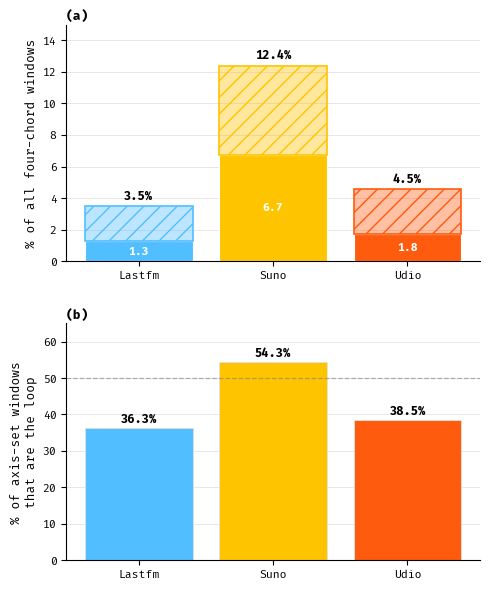

saved -> /workspace/Figures/axis_rotation_breakdown_gate_false.{png,pdf}


In [8]:
# Axis rotation breakdown.  Reads window_counts from the rebuttal cell above.
#   (a) how much of each collection's harmony sits on an axis set, split into the literal
#       loop (solid) and the same four chords reordered (hatched, faded same colour);
#   (b) of those in-set windows, the share that are the literal loop.
import matplotlib.colors as mcolors

_ORD = ['lastfm', 'suno', 'udio']
_LBL = {'lastfm': 'Lastfm', 'suno': 'Suno', 'udio': 'Udio'}

rot_pct, nr_pct, share = {}, {}, {}
for c in _ORD:
    wc    = window_counts[c]
    tot   = sum(wc.values())
    inset = wc['rotation'] + wc['nonrot_inset']
    rot_pct[c] = wc['rotation']     / tot   * 100
    nr_pct[c]  = wc['nonrot_inset'] / tot   * 100
    share[c]   = wc['rotation']     / inset * 100

x = np.arange(len(_ORD))
# stacked (a) over (b), single-column width
fig, (axA, axB) = plt.subplots(2, 1, figsize=(5, 6))

# (a) loop (solid) + reordered (hatched, faded same colour)
for i, c in enumerate(_ORD):
    col = colors[c]
    axA.bar(i, rot_pct[c], color=col, edgecolor='white', linewidth=0.8)
    axA.bar(i, nr_pct[c], bottom=rot_pct[c],
            color=mcolors.to_rgba(col, 0.38), edgecolor=col, linewidth=1.2, hatch='//')
    axA.text(i, rot_pct[c] / 2, f'{rot_pct[c]:.1f}', ha='center', va='center',
             color='white', fontsize=8, fontweight='bold')
    axA.text(i, rot_pct[c] + nr_pct[c] + 0.3, f'{rot_pct[c] + nr_pct[c]:.1f}%',
             ha='center', va='bottom', fontsize=8.5, fontweight='bold')
axA.set_xticks(x); axA.set_xticklabels([_LBL[c] for c in _ORD], fontsize=9)
axA.set_ylabel('% of all four-chord windows', fontsize=9)
axA.set_ylim(0, 15)
axA.tick_params(labelsize=8)
axA.text(0.0, 1.02, '(a)', transform=axA.transAxes, fontsize=9, fontweight='bold')
axA.spines[['top', 'right']].set_visible(False)
axA.grid(axis='y', color='#DDDDDD', linewidth=0.5)
axA.set_axisbelow(True)

# (b) rotation share of in-set windows
sv = [share[c] for c in _ORD]
axB.bar(x, sv, color=[colors[c] for c in _ORD], edgecolor="#e1e1e1", linewidth=0.6)
for i, v in enumerate(sv):
    axB.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
axB.axhline(50, ls='--', lw=0.9, color='grey', alpha=0.6)
axB.set_xticks(x); axB.set_xticklabels([_LBL[c] for c in _ORD], fontsize=9)
axB.set_ylabel('% of axis-set windows\nthat are the loop', fontsize=9)
axB.set_ylim(0, 65)
axB.tick_params(labelsize=8)
axB.text(0.0, 1.02, '(b)', transform=axB.transAxes, fontsize=9, fontweight='bold')
axB.spines[['top', 'right']].set_visible(False)
axB.grid(axis='y', color='#DDDDDD', linewidth=0.5)
axB.set_axisbelow(True)

fig.tight_layout(h_pad=2.0)
os.makedirs('/workspace/Figures', exist_ok=True)
fig.savefig(f'/workspace/Figures/axis_rotation_breakdown{GATE_SUFFIX}.png', dpi=300, bbox_inches='tight')
fig.savefig(f'/workspace/Figures/axis_rotation_breakdown{GATE_SUFFIX}.pdf', bbox_inches='tight')
plt.show()
print(f'saved -> /workspace/Figures/axis_rotation_breakdown{GATE_SUFFIX}.{{png,pdf}}')

## Variant: p-trigram-filtered windowing (pre-2026-07-02 figures)

The figures above count every sliding four-chord window except single-root windows
(the `_gate_false` dataset rule). The earlier version of this analysis kept only
windows whose first three chords are distinct AND whose last three chords are
distinct (each window = a pair of valid p-trigrams). Every axis window has four
distinct chords, so it always passes both filters: the numerators are identical and
the p-trigram filter only shrinks the denominator further, by discarding windows that
contain a non-adjacent repeat such as I,V,I,V. The discard rate is uneven across
collections (about 43% of Lastfm tetragram windows, 29% of Suno, 40% of Udio), so the
filtered rates are higher everywhere and inflate the human corpus the most. The loop
share, panel (b) of the breakdown, is a ratio between two kinds of all-distinct
windows and is untouched.

The two cells below replicate the old figures under the `_ptri` suffix so both variants
sit side by side:
- `tetragram_axis_distribution_ptri.{png,pdf}`
- `axis_rotation_breakdown_ptri.{png,pdf}`

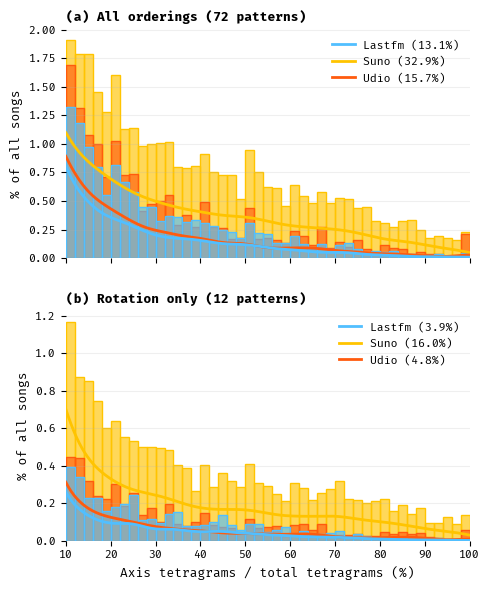

saved -> /workspace/Figures/tetragram_axis_distribution_ptri.{png,pdf}


In [9]:
# ── P-TRIGRAM VARIANT (scan + distribution figure) ──
# Same axis sets and plotting as the tetragram cells above; the ONLY difference is the
# window filter: first-3 distinct AND last-3 distinct (p-trigram pair windowing).
import matplotlib.colors as mcolors
import itertools
from collections import Counter
from scipy.stats import gaussian_kde

_CANON_P = {'major': ('I', 'V', 'vi', 'IV'),
            'minor': ('i', 'bVI', 'III', 'bVII'),
            'mvar':  ('i', 'bVI', 'bIII', 'bVII')}
_CANON_P = {k: tuple(normalize_chord(c) for c in v) for k, v in _CANON_P.items()}
_ROT_P, _PERM_SETS_P = set(), set()
for _c in _CANON_P.values():
    _c = list(_c)
    _ROT_P |= {tuple(_c[i:] + _c[:i]) for i in range(4)}
    _PERM_SETS_P.add(frozenset(_c))

rate_perm_ptri, rate_rot_ptri = {}, {}
window_counts_ptri = {c: Counter() for c in COLLECTIONS}
for col in COLLECTIONS:
    _perm, _rot = [], []
    root = os.path.join(BASE_DIR, col)
    for sid in sorted(os.listdir(root)):
        sd = os.path.join(root, sid)
        fp = os.path.join(sd, f'{sid}_functional.lab')
        if not os.path.isdir(sd) or not os.path.isfile(fp):
            continue
        cps = collapse_repeats(parse_functional_lab(fp))
        wins = [tuple(cps[i:i+4]) for i in range(len(cps) - 3)
                if len(set(cps[i:i+3])) == 3 and len(set(cps[i+1:i+4])) == 3]
        if not wins:
            continue
        mp = mr = 0
        for w in wins:
            if w in _ROT_P:
                window_counts_ptri[col]['rotation'] += 1
                mp += 1; mr += 1
            elif len(set(w)) == 4 and frozenset(w) in _PERM_SETS_P:
                window_counts_ptri[col]['nonrot_inset'] += 1
                mp += 1
            else:
                window_counts_ptri[col]['outset'] += 1
        _perm.append(mp / len(wins) * 100)
        _rot.append(mr / len(wins) * 100)
    rate_perm_ptri[col] = np.array(_perm)
    rate_rot_ptri[col]  = np.array(_rot)

# --- plot (identical styling to the tetragram distribution figure) ---
_LBL  = {'lastfm': 'Lastfm', 'suno': 'Suno', 'udio': 'Udio'}
_BW   = BW if 'BW' in globals() else 0.15
_BINS = np.arange(10, 102, 2)
_XS   = np.linspace(10, 100, 300)
_DRAW = ['suno', 'udio', 'lastfm']
_RATES_P = {'perm': rate_perm_ptri, 'rot': rate_rot_ptri}

fig, axes = plt.subplots(2, 1, figsize=(5, 6), sharex=True)
for ax, (key, title) in zip(
        axes,
        [('perm', '(a) All orderings (72 patterns)'),
         ('rot',  '(b) Rotation only (12 patterns)')]):
    line_by_col, label_by_col = {}, {}
    for col in _DRAW:
        r      = _RATES_P[key][col]
        disp   = r[r >= 10]
        allpos = r[r > 0]
        n_all  = len(r)
        frac_disp = len(disp) / n_all
        frac_kde  = len(allpos) / n_all
        w = np.ones_like(disp) / n_all * 100
        ax.hist(disp, bins=_BINS, weights=w,
                facecolor=mcolors.to_rgba(colors[col], alpha=0.65),
                edgecolor=colors[col], linewidth=1.0)
        if len(allpos) >= 2:
            kde = gaussian_kde(allpos, bw_method=_BW)
            lbl = f'{_LBL[col]} ({frac_disp * 100:.1f}%)'
            line, = ax.plot(_XS, kde(_XS) * frac_kde * 100, color=colors[col],
                            linewidth=2.0)
            line_by_col[col] = line
            label_by_col[col] = lbl
    ax.set_ylabel('% of all songs', fontsize=9)
    ax.set_xlim(10, 100)
    ax.set_title(title, fontsize=9, fontweight='bold', loc='left')
    ax.grid(True, axis='y', alpha=0.2)
    for spine in ax.spines.values():
        spine.set_visible(False)
    _ord = [c for c in ['lastfm', 'suno', 'udio'] if c in line_by_col]
    ax.tick_params(labelsize=8)
    ax.legend([line_by_col[c] for c in _ord], [label_by_col[c] for c in _ord],
              fontsize=8, frameon=False)
axes[1].set_xlabel('Axis tetragrams / total tetragrams (%)', fontsize=9)
plt.tight_layout(h_pad=2.0)
os.makedirs('/workspace/Figures', exist_ok=True)
plt.savefig('/workspace/Figures/tetragram_axis_distribution_ptri.png', dpi=300, bbox_inches='tight')
plt.savefig('/workspace/Figures/tetragram_axis_distribution_ptri.pdf', bbox_inches='tight')
plt.show()
print('saved -> /workspace/Figures/tetragram_axis_distribution_ptri.{png,pdf}')

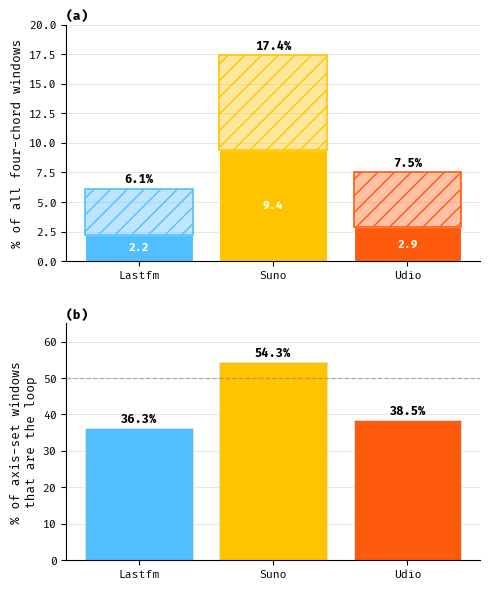

saved -> /workspace/Figures/axis_rotation_breakdown_ptri.{png,pdf}

=== WINDOW LEVEL ===
     col      variant     windows  inset%  loop% loopshare%
  lastfm    tetragram   1,396,018     3.5    1.3       36.3
  lastfm    p-trigram     793,923     6.1    2.2       36.3
    suno    tetragram   1,372,615    12.4    6.7       54.3
    suno    p-trigram     979,148    17.4    9.4       54.3
    udio    tetragram     917,453     4.5    1.8       38.5
    udio    p-trigram     552,861     7.5    2.9       38.5

=== PER-SONG >=10% AXIS RATE ===
     col      variant  n_songs  perm72%  rot12%
  lastfm    tetragram   18,721      8.6     2.8
  lastfm    p-trigram   18,245     13.1     3.9
    suno    tetragram   18,794     28.0    13.6
    suno    p-trigram   18,461     32.9    16.0
    udio    tetragram   18,663     10.5     3.4
    udio    p-trigram   17,783     15.7     4.8

=== SUNO / LASTFM RATIO at >=10% ===
   tetragram: perm72 3.2x   rot12 4.8x
   p-trigram: perm72 2.5x   rot12 4.1x


In [10]:
# ── P-TRIGRAM VARIANT (rotation breakdown figure + numeric comparison) ──
# Reads window_counts_ptri from the cell above; same styling as the tetragram
# breakdown figure. Then prints filtered vs unfiltered numbers side by side
# (window_counts / rate_perm / rate_rot come from the tetragram cells).
import matplotlib.colors as mcolors

_ORD = ['lastfm', 'suno', 'udio']
_LBL = {'lastfm': 'Lastfm', 'suno': 'Suno', 'udio': 'Udio'}

rot_pct, nr_pct, share = {}, {}, {}
for c in _ORD:
    wc    = window_counts_ptri[c]
    tot   = sum(wc.values())
    inset = wc['rotation'] + wc['nonrot_inset']
    rot_pct[c] = wc['rotation']     / tot   * 100
    nr_pct[c]  = wc['nonrot_inset'] / tot   * 100
    share[c]   = wc['rotation']     / inset * 100

x = np.arange(len(_ORD))
fig, (axA, axB) = plt.subplots(2, 1, figsize=(5, 6))

for i, c in enumerate(_ORD):
    col = colors[c]
    axA.bar(i, rot_pct[c], color=col, edgecolor='white', linewidth=0.8)
    axA.bar(i, nr_pct[c], bottom=rot_pct[c],
            color=mcolors.to_rgba(col, 0.38), edgecolor=col, linewidth=1.2, hatch='//')
    axA.text(i, rot_pct[c] / 2, f'{rot_pct[c]:.1f}', ha='center', va='center',
             color='white', fontsize=8, fontweight='bold')
    axA.text(i, rot_pct[c] + nr_pct[c] + 0.3, f'{rot_pct[c] + nr_pct[c]:.1f}%',
             ha='center', va='bottom', fontsize=8.5, fontweight='bold')
axA.set_xticks(x); axA.set_xticklabels([_LBL[c] for c in _ORD], fontsize=9)
axA.set_ylabel('% of all four-chord windows', fontsize=9)
axA.set_ylim(0, 20)
axA.tick_params(labelsize=8)
axA.text(0.0, 1.02, '(a)', transform=axA.transAxes, fontsize=9, fontweight='bold')
axA.spines[['top', 'right']].set_visible(False)
axA.grid(axis='y', color='#DDDDDD', linewidth=0.5)
axA.set_axisbelow(True)

sv = [share[c] for c in _ORD]
axB.bar(x, sv, color=[colors[c] for c in _ORD], edgecolor="#e1e1e1", linewidth=0.6)
for i, v in enumerate(sv):
    axB.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
axB.axhline(50, ls='--', lw=0.9, color='grey', alpha=0.6)
axB.set_xticks(x); axB.set_xticklabels([_LBL[c] for c in _ORD], fontsize=9)
axB.set_ylabel('% of axis-set windows\nthat are the loop', fontsize=9)
axB.set_ylim(0, 65)
axB.tick_params(labelsize=8)
axB.text(0.0, 1.02, '(b)', transform=axB.transAxes, fontsize=9, fontweight='bold')
axB.spines[['top', 'right']].set_visible(False)
axB.grid(axis='y', color='#DDDDDD', linewidth=0.5)
axB.set_axisbelow(True)

fig.tight_layout(h_pad=2.0)
fig.savefig('/workspace/Figures/axis_rotation_breakdown_ptri.png', dpi=300, bbox_inches='tight')
fig.savefig('/workspace/Figures/axis_rotation_breakdown_ptri.pdf', bbox_inches='tight')
plt.show()
print('saved -> /workspace/Figures/axis_rotation_breakdown_ptri.{png,pdf}')

# ── Numeric comparison: unfiltered tetragram (current) vs p-trigram filter (old) ──
print()
print('=== WINDOW LEVEL ===')
print(f'{"col":>8} {"variant":>12} {"windows":>11} {"inset%":>7} {"loop%":>6} {"loopshare%":>10}')
for c in _ORD:
    for tag, wc in [('tetragram', window_counts[c]), ('p-trigram', window_counts_ptri[c])]:
        tot = sum(wc.values())
        inset = wc['rotation'] + wc['nonrot_inset']
        print(f'{c:>8} {tag:>12} {tot:>11,} {inset/tot*100:>7.1f} '
              f'{wc["rotation"]/tot*100:>6.1f} {wc["rotation"]/inset*100:>10.1f}')

print()
print('=== PER-SONG >=10% AXIS RATE ===')
print(f'{"col":>8} {"variant":>12} {"n_songs":>8} {"perm72%":>8} {"rot12%":>7}')
for c in _ORD:
    for tag, rp, rr in [('tetragram', np.asarray(rate_perm[c]), np.asarray(rate_rot[c])),
                        ('p-trigram', rate_perm_ptri[c], rate_rot_ptri[c])]:
        print(f'{c:>8} {tag:>12} {len(rp):>8,} '
              f'{(rp >= 10).mean()*100:>8.1f} {(rr >= 10).mean()*100:>7.1f}')

print()
print('=== SUNO / LASTFM RATIO at >=10% ===')
for tag, rp, rr in [('tetragram', rate_perm, rate_rot),
                    ('p-trigram', rate_perm_ptri, rate_rot_ptri)]:
    def _p(d, c):
        a = np.asarray(d[c]); return (a >= 10).mean() * 100
    print(f'  {tag:>10}: perm72 {_p(rp, "suno")/_p(rp, "lastfm"):.1f}x   '
          f'rot12 {_p(rr, "suno")/_p(rr, "lastfm"):.1f}x')

## Cross-check: axis presence from the tetragram dataset

The rebuttal cell computes axis rates by scanning `_functional.lab` files directly. This section recomputes the same three-way window classification from the exported tetragram dataset (`ngram_datasets/tetragrams/4gram_dataset_*_ace*.json`), an independently constructed artifact, and compares the two. Numerators must agree. Under the `_gate_false` variant both sides use the same window rule (every window after consecutive de-duplication, single-root windows excluded), so denominators and rates should also match up to the enharmonic-collapse residual described in the code cell.

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# CROSS-CHECK — axis presence recomputed from the tetragram dataset JSONs
# -----------------------------------------------------------------------------
# The rebuttal cell above scans _functional.lab files directly. Here we recompute
# the same window-level classification from the exported tetragram dataset
# (ngram_datasets/tetragrams/4gram_dataset_{collection}_ace.json, built by
# forming_n_gram_datasets_ACE.ipynb from the same _functional.lab corpus), so the
# paper's axis numbers are verified against an independently constructed artifact.
#
# Expected relationship, stated up front:
#   * NUMERATORS (rotation / reordered-in-set counts) should agree almost exactly.
#     Tiny deltas are possible only because the scan normalises enharmonic
#     spellings BEFORE collapsing repeats, while the dataset collapses raw labels
#     first (two adjacent labels that normalise to the same chord stay separate).
#   * DENOMINATORS: under the legacy gated dataset (>=3-of-4 distinct,
#     case-insensitive) only non-axis windows are removed, so dataset rates sit
#     slightly above the scan rates. Under the _gate_false dataset both
#     populations use the same rule (all windows after consecutive dedup, minus
#     single-root windows), so totals and rates should match the scan almost
#     exactly (residual = the enharmonic-collapse difference).
#
# Reads ROTATIONS / SET_TO_NAME / classify_window / window_counts / rate_perm /
# rate_rot / n_songs from the rebuttal cell above.
import json as _json

TETRA_DIR = '/workspace/ngram_datasets/tetragrams'
# '' = legacy gated dataset (>=3-of-4-distinct, case-insensitive retention rule);
# '_gate_false' = every window after consecutive dedup except single-root windows
TETRA_SUFFIX = GATE_SUFFIX

ds_counts, ds_songs_perm, ds_songs_rot = {}, {}, {}
for col in COLLECTIONS:
    with open(os.path.join(TETRA_DIR, f'4gram_dataset_{col}_ace{TETRA_SUFFIX}.json')) as f:
        entries = _json.load(f)
    cnt = Counter()
    songs_perm, songs_rot = set(), set()
    for e in entries:
        w = tuple(normalize_chord(c) for c in e['ngram'])
        cat = classify_window(w)
        cnt[cat] += e['count']
        if cat == 'rotation':
            songs_rot.update(e['song_ids'])
            songs_perm.update(e['song_ids'])
        elif cat == 'nonrot_inset':
            songs_perm.update(e['song_ids'])
    ds_counts[col] = cnt
    ds_songs_perm[col] = songs_perm
    ds_songs_rot[col] = songs_rot

# ── 1. numerators: absolute window counts, scan vs dataset ────────────────────
print(f'Dataset variant: {TETRA_SUFFIX or "legacy (gated)"}')
print('=== NUMERATORS: axis window counts, scan vs tetragram dataset ===')
print(f'{"collection":>10} {"rot(scan)":>11} {"rot(ds)":>11} {"delta":>7}   '
      f'{"nonrot(scan)":>13} {"nonrot(ds)":>11} {"delta":>7}')
for col in COLLECTIONS:
    sc, ds = window_counts[col], ds_counts[col]
    d_rot = ds['rotation'] - sc['rotation']
    d_nr  = ds['nonrot_inset'] - sc['nonrot_inset']
    print(f'{col:>10} {sc["rotation"]:>11,} {ds["rotation"]:>11,} {d_rot:>+7,}   '
          f'{sc["nonrot_inset"]:>13,} {ds["nonrot_inset"]:>11,} {d_nr:>+7,}')

# ── 2. rates under each denominator ───────────────────────────────────────────
print('\n=== RATES: % of windows that are axis (family = rotation + reordered) ===')
print(f'{"collection":>10} {"windows(scan)":>14} {"family(scan)":>13} {"rot(scan)":>10}   '
      f'{"windows(ds)":>12} {"family(ds)":>11} {"rot(ds)":>9}')
for col in COLLECTIONS:
    sc, ds = window_counts[col], ds_counts[col]
    sc_tot, ds_tot = sum(sc.values()), sum(ds.values())
    sc_fam = sc['rotation'] + sc['nonrot_inset']
    ds_fam = ds['rotation'] + ds['nonrot_inset']
    print(f'{col:>10} {sc_tot:>14,} {sc_fam/sc_tot*100:>12.2f}% {sc["rotation"]/sc_tot*100:>9.2f}%   '
          f'{ds_tot:>12,} {ds_fam/ds_tot*100:>10.2f}% {ds["rotation"]/ds_tot*100:>8.2f}%')

# ── 3. loop share among in-set windows (the Table 2 companion number) ─────────
print('\n=== LOOP SHARE among axis-set windows: rotation / (rotation + reordered) ===')
print(f'{"collection":>10} {"scan":>8} {"dataset":>9}')
for col in COLLECTIONS:
    sc, ds = window_counts[col], ds_counts[col]
    sc_share = sc['rotation'] / (sc['rotation'] + sc['nonrot_inset']) * 100
    ds_share = ds['rotation'] / (ds['rotation'] + ds['nonrot_inset']) * 100
    print(f'{col:>10} {sc_share:>7.1f}% {ds_share:>8.1f}%')

# ── 4. song-level presence: songs with at least one axis window ───────────────
print('\n=== SONG PRESENCE: songs containing at least one axis window ===')
print(f'{"collection":>10} {"family(scan)":>13} {"family(ds)":>11}   {"rot(scan)":>10} {"rot(ds)":>8}')
for col in COLLECTIONS:
    sc_perm = int((np.array(rate_perm[col]) > 0).sum())
    sc_rot  = int((np.array(rate_rot[col])  > 0).sum())
    print(f'{col:>10} {sc_perm:>13,} {len(ds_songs_perm[col]):>11,}   '
          f'{sc_rot:>10,} {len(ds_songs_rot[col]):>8,}')

print('\nCross-check complete against dataset variant:', TETRA_SUFFIX or 'legacy (gated)')

Dataset variant: _gate_false
=== NUMERATORS: axis window counts, scan vs tetragram dataset ===
collection   rot(scan)     rot(ds)   delta    nonrot(scan)  nonrot(ds)   delta
    lastfm      17,621      17,585     -36          30,954      30,873     -81
      suno      92,386      92,298     -88          77,855      77,783     -72
      udio      16,057      16,040     -17          25,681      25,585     -96

=== RATES: % of windows that are axis (family = rotation + reordered) ===
collection  windows(scan)  family(scan)  rot(scan)    windows(ds)  family(ds)   rot(ds)
    lastfm      1,396,018         3.48%      1.26%      1,399,311       3.46%     1.26%
      suno      1,372,615        12.40%      6.73%      1,373,650      12.38%     6.72%
      udio        917,453         4.55%      1.75%        919,083       4.53%     1.75%

=== LOOP SHARE among axis-set windows: rotation / (rotation + reordered) ===
collection     scan   dataset
    lastfm    36.3%     36.3%
      suno    54.3%     